# Exp 6: Credit Risk Assessment: Build a credit scoring model to assess the creditworthiness of applicants using historical financial data and perform comparative analysis (Logistic Regression, Random Forest, XGBoost)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Logistic Regression
Accuracy: 0.74
Precision: 0.7031151699644849
Recall: 0.74
F1 Macro: 0.48314249363867684
F1 Micro: 0.74
F1 Weighted: 0.7094179389312977
ROC-AUC: 0.8138054959289079


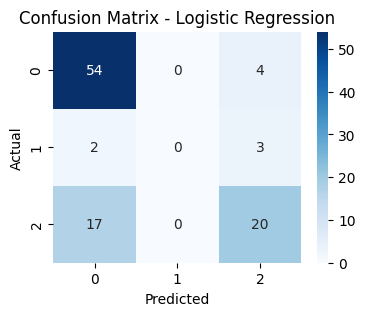

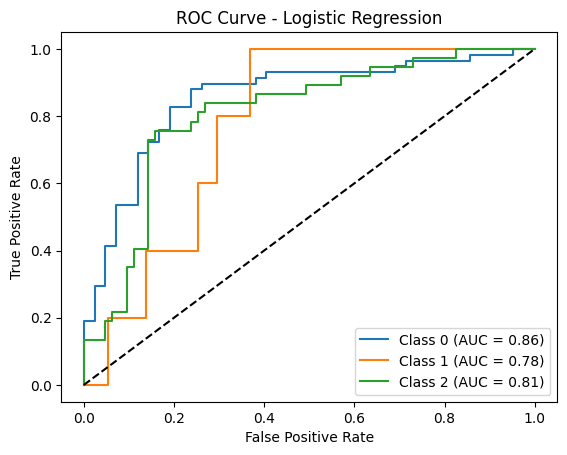


Model: Random Forest
Accuracy: 0.98
Precision: 0.981025641025641
Recall: 0.98
F1 Macro: 0.9078947368421053
F1 Micro: 0.98
F1 Weighted: 0.9777631578947369
ROC-AUC: 0.9996424996424996


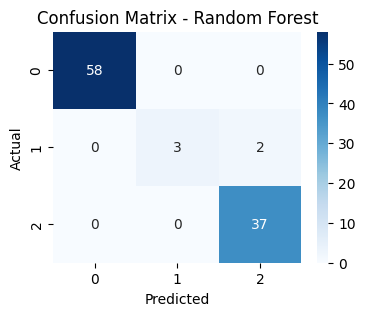

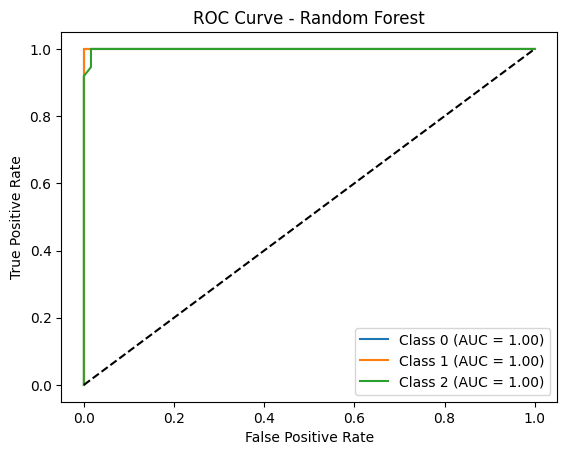


Model: XGBoost
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Macro: 1.0
F1 Micro: 1.0
F1 Weighted: 1.0
ROC-AUC: 1.0


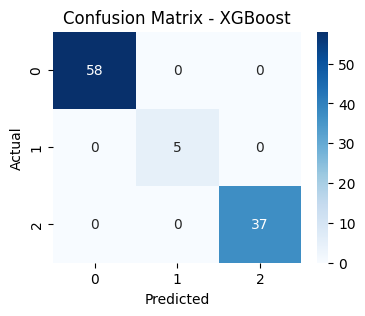

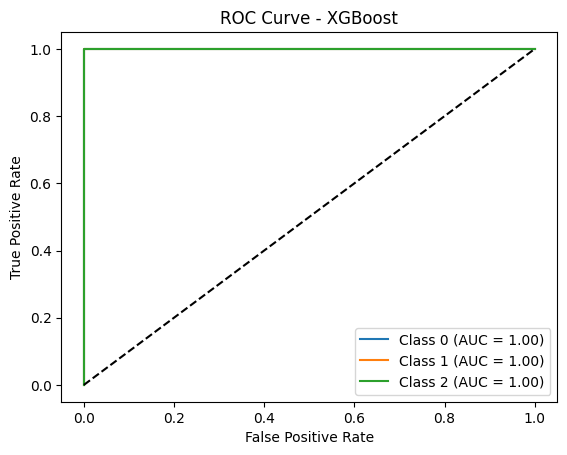


Comparative Analysis:
                 Model  Accuracy  Precision  Recall  F1 Macro  F1 Micro  \
0  Logistic Regression      0.74   0.703115    0.74  0.483142      0.74   
1        Random Forest      0.98   0.981026    0.98  0.907895      0.98   
2              XGBoost      1.00   1.000000    1.00  1.000000      1.00   

   F1 Weighted   ROC-AUC  
0     0.709418  0.813805  
1     0.977763  0.999642  
2     1.000000  1.000000  


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/ML_LAB/credit_risk_assessment_500_samples.csv")

# Encode target
le = LabelEncoder()
df["Credit_Risk"] = le.fit_transform(df["Credit_Risk"])

# Features and target
X = df.drop(["Applicant_ID","Credit_Risk"], axis=1)
y = df["Credit_Risk"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="mlogloss")
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)

    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_micro = f1_score(y_test, y_pred, average="micro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    roc = roc_auc_score(y_test, y_prob, multi_class="ovr")

    print("\nModel:", name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Macro:", f1_macro)
    print("F1 Micro:", f1_micro)
    print("F1 Weighted:", f1_weighted)
    print("ROC-AUC:", roc)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    results.append([name, acc, prec, rec, f1_macro, f1_micro, f1_weighted, roc])

    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc

    # Binarize the output
    n_classes = len(set(y))
    y_test_bin = label_binarize(y_test, classes=range(n_classes))

    # Plot ROC curve
    plt.figure()

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

    # Diagonal line
    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend()
    plt.show()

# Comparative analysis
results_df = pd.DataFrame(
    results,
    columns=[
        "Model","Accuracy","Precision","Recall",
        "F1 Macro","F1 Micro","F1 Weighted","ROC-AUC"
    ]
)

print("\nComparative Analysis:")
print(results_df)